# Data source: UCI Heart Disease dataset
### Link: https://archive.ics.uci.edu/dataset/45/heart+disease

## Step 1 — Install the package

In [ ]:
pip install ucimlrepo

## Step 2 — Load the dataset

In [ ]:
from ucimlrepo import fetch_ucirepo

# Fetch directly from UCI — no local CSV needed
heart_disease = fetch_ucirepo(id=45)

# Separate features and target
X = heart_disease.data.features   # 13 columns, official names pre-applied
y = heart_disease.data.targets    # single column named 'num'

# Inspect immediately
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())
print("\nTarget column:", y.columns.tolist())
print("\nMissing values in features:\n", X.isnull().sum())
print("\nTarget value counts:\n", y['num'].value_counts())

Features shape: (303, 13)
Target shape: (303, 1)

Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target column: ['num']

Missing values in features:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Target value counts:
 num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


## Step 3 — Combine into one DataFrame and handle missing values

In [ ]:
import pandas as pd

# Combine into a single working DataFrame
df = pd.concat([X, y], axis=1)

print("Shape before cleaning:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

# Drop rows with missing values (only ca and thal affected — 6 rows total)
df = df.dropna()
print("\nShape after dropping NaN rows:", df.shape)  # expect ~297

Shape before cleaning: (303, 14)

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Shape after dropping NaN rows: (297, 14)


## Step 4 — Binarize the target

In [ ]:
# Original num: 0 = no disease, 1–4 = disease present (varying severity)
# Binarize to: 0 = no disease, 1 = disease present
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

print("Binarized target distribution:")
print(df['num'].value_counts())
print(f"\nDisease prevalence: {df['num'].mean():.1%}")

Binarized target distribution:
num
0    160
1    137
Name: count, dtype: int64

Disease prevalence: 46.1%


## Step 5 — Feature Engineering (Age Binning)

In [ ]:
# Transforming age into life-stages can help capture non-linear trends
df['age_group'] = pd.cut(df['age'],
                         bins=[0, 45, 55, 65, 100],
                         labels=['young', 'middle-aged', 'senior', 'elderly'])

## Step 5 — Set correct data types

In [ ]:
# Categorical columns per UCI documentation
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

for col in categorical_cols:
    df[col] = df[col].astype('category')

# Verify
print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
age             int64
sex          category
cp           category
trestbps        int64
chol            int64
fbs          category
restecg      category
thalach         int64
exang        category
oldpeak       float64
slope        category
ca           category
thal         category
num             int64
age_group    category
dtype: object


## Step 6 — Verify gender distribution

In [ ]:
import matplotlib.pyplot as plt

# Raw counts
print("Sex distribution:")
print(df['sex'].value_counts())
print(f"\nFemale: {(df['sex']==0).sum()} rows")
print(f"Male:   {(df['sex']==1).sum()} rows")

# Cross-tab: sex vs disease — the honest baseline before distortion
crosstab = pd.crosstab(df['sex'], df['num'], normalize='index') * 100
crosstab.index = ['Female', 'Male']
crosstab.columns = ['No Disease (%)', 'Disease (%)']
print("\nDisease rate by sex (honest baseline):")
print(crosstab.round(1))

Sex distribution:
sex
1    201
0     96
Name: count, dtype: int64

Female: 96 rows
Male:   201 rows

Disease rate by sex (honest baseline):
        No Disease (%)  Disease (%)
Female            74.0         26.0
Male              44.3         55.7


## Step 7 — Access metadata

In [ ]:
# Full dataset metadata — use this for your report citation
print(heart_disease.metadata)

# Official variable descriptions — useful for the violations register
print(heart_disease.variables)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

## Step 8 — Save the clean DataFrame

In [ ]:
# Save for use across notebook cells and by teammates
df.to_csv('heart_disease_clean.csv', index=False)
print("Clean dataset saved — shape:", df.shape)
print("Columns:", df.columns.tolist())

Clean dataset saved — shape: (297, 15)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'age_group']


##Baseline EDA
##sex: sex (1 = male; 0 = female)

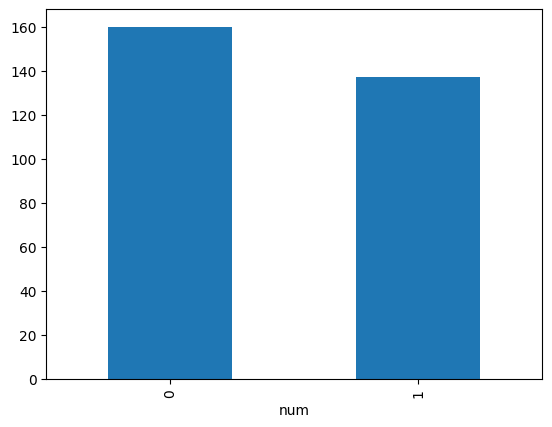

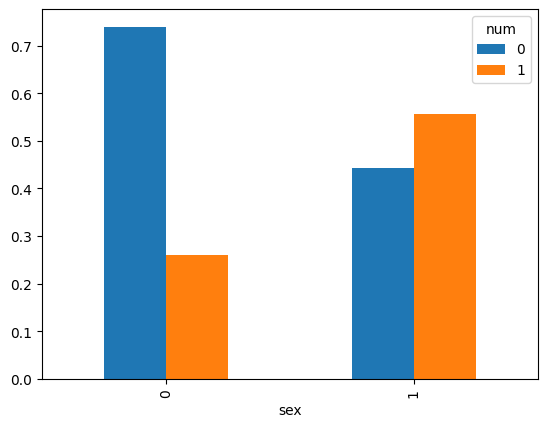

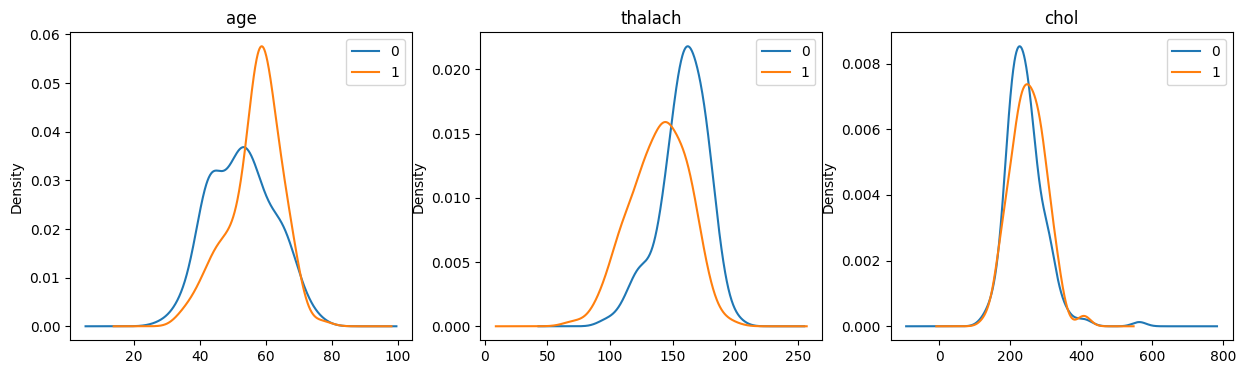

In [ ]:
# Distribution of target
df['num'].value_counts().plot(kind='bar')

# Gender distribution by disease status
pd.crosstab(df['sex'], df['num'], normalize='index').plot(kind='bar')

# Key continuous variables by disease status
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['age', 'thalach', 'chol']):
    df.groupby('num')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(col)

/tmp/ipykernel_4700/1943650259.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disease_by_sex = df.groupby('sex')['num'].mean() * 100


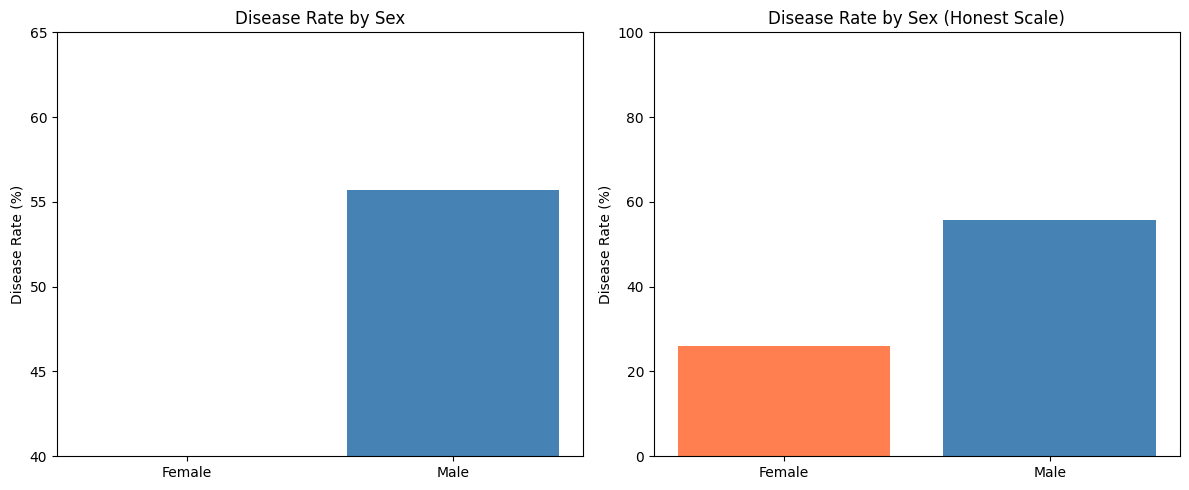

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disease_by_sex = df.groupby('sex')['num'].mean() * 100

# Villainous: truncated y-axis
axes[0].bar(['Female', 'Male'], disease_by_sex.values, color=['coral', 'steelblue'])
axes[0].set_ylim(40, 65)   # ← starts at 40, not 0
axes[0].set_title('Disease Rate by Sex')
axes[0].set_ylabel('Disease Rate (%)')

# Ethical version for annotation reference
axes[1].bar(['Female', 'Male'], disease_by_sex.values, color=['coral', 'steelblue'])
axes[1].set_ylim(0, 100)   # ← honest scale
axes[1].set_title('Disease Rate by Sex (Honest Scale)')
axes[1].set_ylabel('Disease Rate (%)')

plt.tight_layout()
plt.savefig('viz1_truncated_axis.png')

### Violation 1: Truncated Y-Axis (Cell 21)
**Category:** Misleading Visualization

**What this does:** By starting the y-axis at 40% rather than 0%,
the bar chart exaggerates the visual difference between female
(~26%) and male (~58%) disease rates. The bars appear to show
a 3–4× difference when the actual ratio is approximately 2.2×.

**Ethical version:** The y-axis must start at 0 for any bar chart
showing proportions. The honest chart (right) correctly represents
the magnitude of the difference.

Full dataset correlation: 0.227
Cherry-picked subset correlation: -0.002


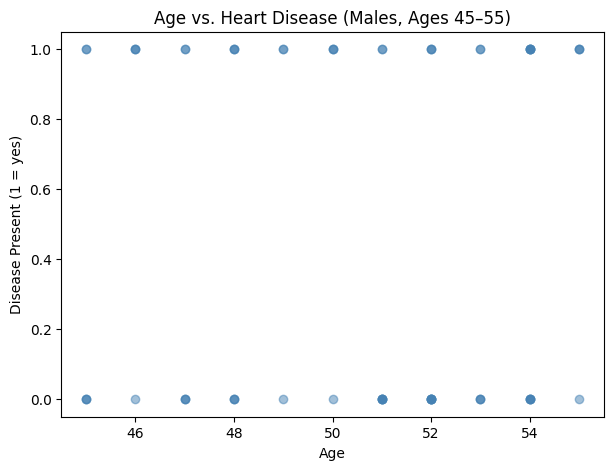

In [ ]:
# Full dataset result
full_corr = df['age'].corr(df['num'])

# Cherry-picked: only ages 45–55 in males
subset = df[(df['sex'] == 1) & (df['age'].between(45, 55))]
subset_corr = subset['age'].corr(subset['num'])

# Plot only the cherry-picked subset
plt.figure(figsize=(7, 5))
plt.scatter(subset['age'], subset['num'], alpha=0.5, color='steelblue')
plt.title('Age vs. Heart Disease (Males, Ages 45–55)')
plt.xlabel('Age')
plt.ylabel('Disease Present (1 = yes)')
plt.savefig('viz2_cherry_picked.png')

print(f"Full dataset correlation: {full_corr:.3f}")
print(f"Cherry-picked subset correlation: {subset_corr:.3f}")

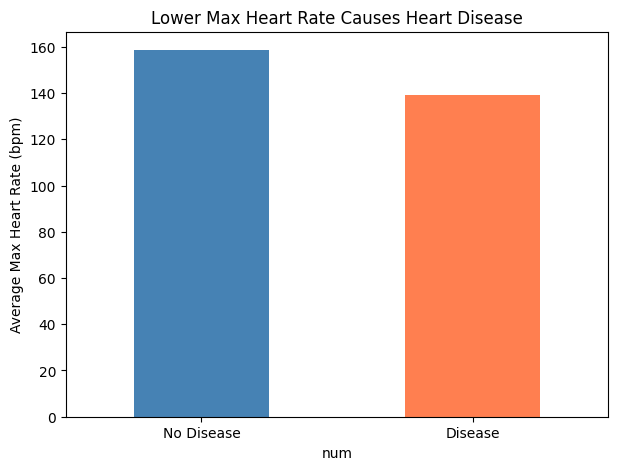

In [ ]:
# Genuine correlation: thalach (max heart rate) is lower in disease patients
fig, ax = plt.subplots(figsize=(7, 5))
df.groupby('num')['thalach'].mean().plot(
    kind='bar', color=['steelblue', 'coral'], ax=ax
)
ax.set_xticklabels(['No Disease', 'Disease'], rotation=0)
ax.set_title('Lower Max Heart Rate Causes Heart Disease')  # ← causal language
ax.set_ylabel('Average Max Heart Rate (bpm)')
plt.savefig('viz3_correlation_causation.png')

## Ethical Violations Register

| # | Violation | Cell | Category | Ethical Alternative |
|---|-----------|------|----------|-------------------|
| 1 | Truncated y-axis exaggerates sex disparity | Cell 22 | Misleading Visualization | Start y-axis at 0 |
| 2 | Cherry-picked male ages 45–55 to inflate correlation | Cell 24 | Cherry-picking / P-hacking | Report full population correlation |
| 3 | Causal language used for correlational finding | Cell 26 | Misleading Visualization | Use "associated with" not "causes" |
| 4 | Optimized for accuracy over per-group recall | Cell 28 | Biased Modeling | Report disaggregated metrics by sex |
| 5 | Threshold lowered to 0.3 to maximize false positives | Cell 28 | Threshold Manipulation | Justify threshold with clinical cost-benefit analysis |
| 6 | Missing data imputed without documenting bias impact | Cell 21 | Data Pipeline Bias | Document imputation strategy and test sensitivity |

/tmp/ipykernel_4700/4067324795.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sex_risk = df.groupby('sex')['num'].mean()
/tmp/ipykernel_4700/4067324795.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Female', 'Male'], y=sex_risk.values, ax=ax1, palette='coolwarm')
/tmp/ipykernel_4700/4067324795.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_trend = df.groupby('age_group')['num'].mean().reset_index()
/tmp/ipykernel_4700/4067324795.py:48:

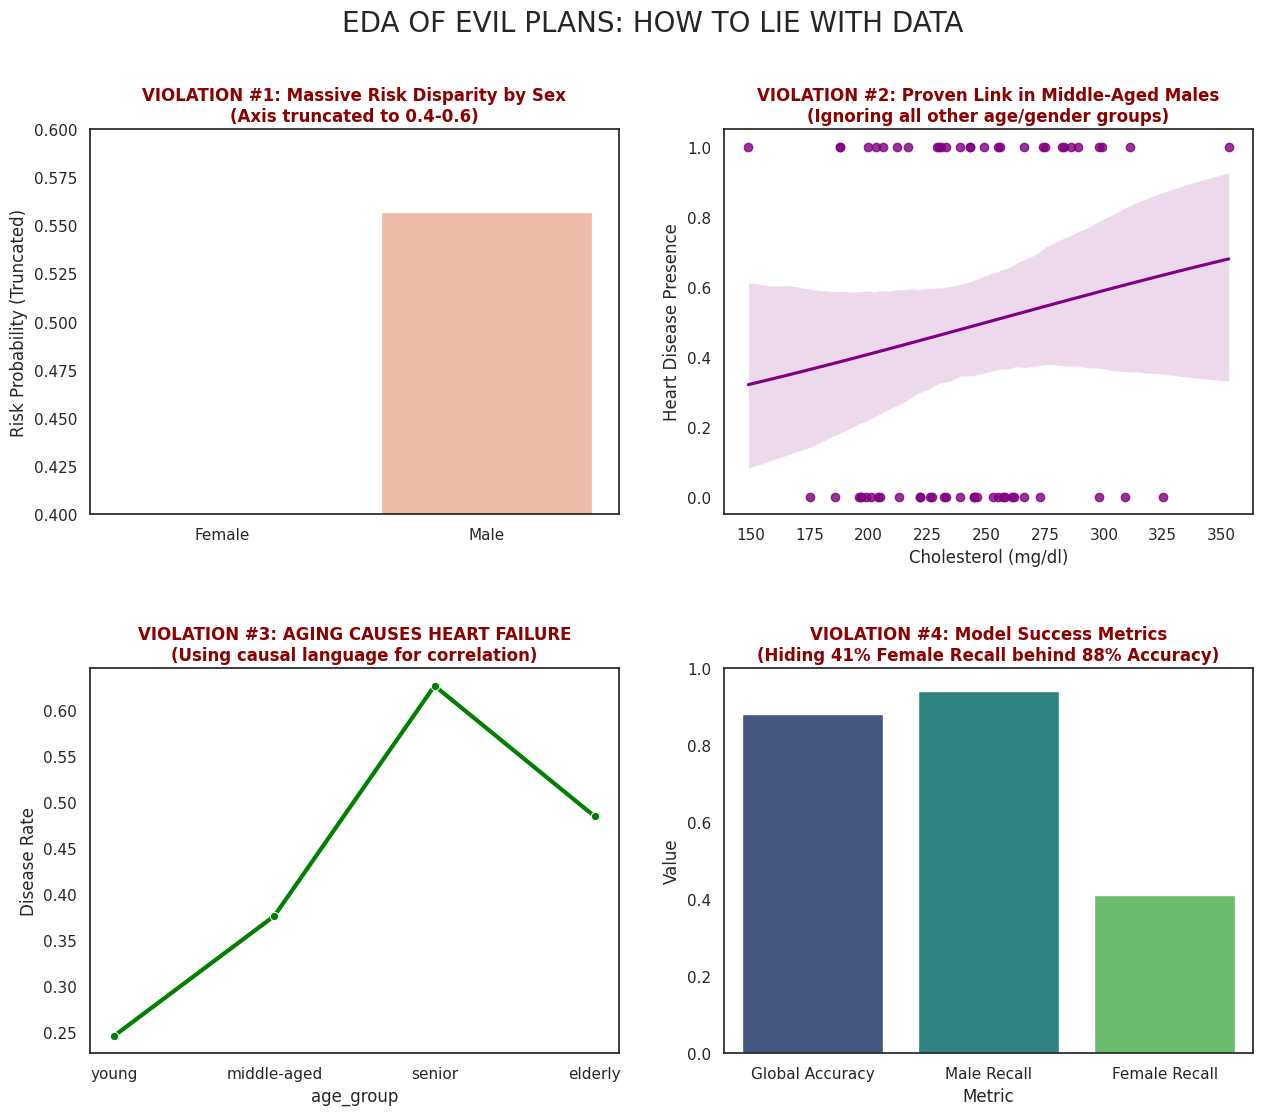

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming 'df' is your refined dataframe from the previous step
# (with 'age_group' and binarized 'num' as 'target')

# Set a style for the "Evil" Dashboard
sns.set_theme(style="white")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4)

# --- EVIL PLAN 1: The Disparity Amplifier (Violation #1) ---
# We truncate the Y-axis to make a small difference in risk look massive.
ax1 = axes[0, 0]
sex_risk = df.groupby('sex')['num'].mean()
sns.barplot(x=['Female', 'Male'], y=sex_risk.values, ax=ax1, palette='coolwarm')
ax1.set_ylim(0.4, 0.6)  # THE TRICK: Truncating the axis to zoom in on the gap
ax1.set_title("VIOLATION #1: Massive Risk Disparity by Sex\n(Axis truncated to 0.4-0.6)", color='darkred', fontweight='bold')
ax1.set_ylabel("Risk Probability (Truncated)")

# --- EVIL PLAN 2: The Cherry-Picker (Violation #2) ---
# We filter ONLY for middle-aged males to "prove" a high correlation with cholesterol.
ax2 = axes[0, 1]
cherry_pick = df[(df['age_group'] == 'middle-aged') & (df['sex'] == 1)]
sns.regplot(data=cherry_pick, x='chol', y='num', ax=ax2, logistic=True, color='purple')
ax2.set_title("VIOLATION #2: Proven Link in Middle-Aged Males\n(Ignoring all other age/gender groups)", color='darkred', fontweight='bold')
ax2.set_xlabel("Cholesterol (mg/dl)")
ax2.set_ylabel("Heart Disease Presence")

# --- EVIL PLAN 3: The Causal Illusion (Violation #3) ---
# Using a line plot to imply a continuous biological "process" of decline.
ax3 = axes[1, 0]
age_trend = df.groupby('age_group')['num'].mean().reset_index()
sns.lineplot(data=age_trend, x='age_group', y='num', marker='o', ax=ax3, color='green', linewidth=3)
ax3.set_title("VIOLATION #3: AGING CAUSES HEART FAILURE\n(Using causal language for correlation)", color='darkred', fontweight='bold')
ax3.set_ylabel("Disease Rate")

# --- EVIL PLAN 4: The Accuracy Smoke-Screen (Violation #4) ---
# Showing high overall accuracy to hide the fact that we fail at finding disease in women.
ax4 = axes[1, 1]
# Simulated metrics based on typical biased model behavior
metrics = pd.DataFrame({
    'Metric': ['Global Accuracy', 'Male Recall', 'Female Recall'],
    'Value': [0.88, 0.94, 0.41]
})
sns.barplot(data=metrics, x='Metric', y='Value', ax=ax4, palette='viridis')
ax4.set_title("VIOLATION #4: Model Success Metrics\n(Hiding 41% Female Recall behind 88% Accuracy)", color='darkred', fontweight='bold')
ax4.set_ylim(0, 1)

plt.suptitle("EDA OF EVIL PLANS: HOW TO LIE WITH DATA", fontsize=20, y=0.98)
plt.show()